In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.autograd import Variable

In [8]:
# Load the dataset
df = pd.read_csv('coin_Aave.csv')

# Ensure data is loaded correctly
print(df.head())

   SNo  Name Symbol                 Date       High        Low       Open  \
0    1  Aave   AAVE  2020-10-05 23:59:59  55.112358  49.787900  52.675035   
1    2  Aave   AAVE  2020-10-06 23:59:59  53.402270  40.734578  53.291969   
2    3  Aave   AAVE  2020-10-07 23:59:59  42.408314  35.970690  42.399947   
3    4  Aave   AAVE  2020-10-08 23:59:59  44.902511  36.696057  39.885262   
4    5  Aave   AAVE  2020-10-09 23:59:59  47.569533  43.291776  43.764463   

       Close        Volume     Marketcap  
0  53.219243  0.000000e+00  8.912813e+07  
1  42.401599  5.830915e+05  7.101144e+07  
2  40.083976  6.828342e+05  6.713004e+07  
3  43.764463  1.658817e+06  2.202651e+08  
4  46.817744  8.155377e+05  2.356322e+08  


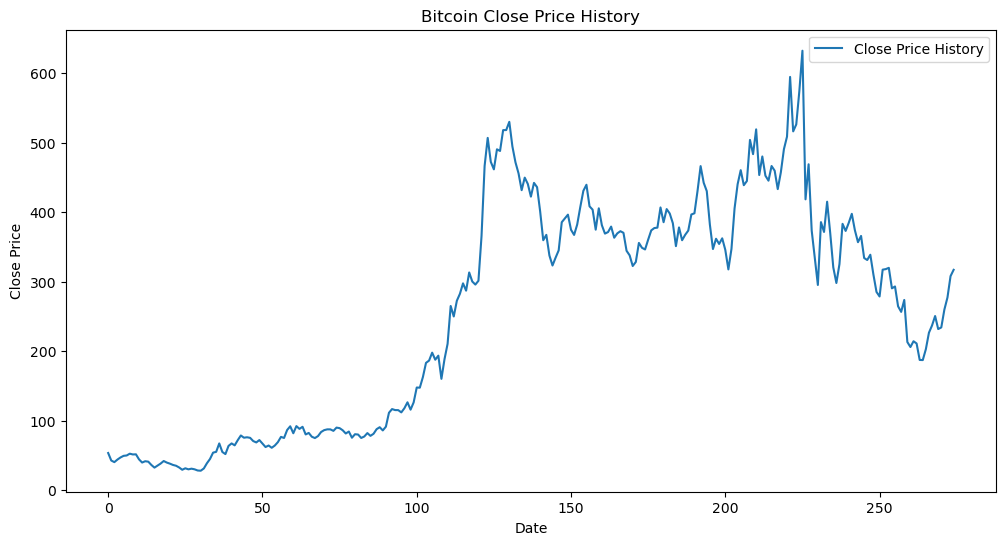

In [10]:
# Plot the original data
plt.figure(figsize=(12,6))
plt.plot(df['Close'], label='Close Price History')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Bitcoin Close Price History')
plt.legend()
plt.show()

In [12]:

# Data preprocessing
data = df.filter(['Close']).values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [14]:
# Define a function to create the training dataset
def create_dataset(dataset, time_step):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

In [16]:
# Define the time step for the LSTM model
time_step = 60
X, y = create_dataset(scaled_data, time_step)

In [18]:
# Reshape data for LSTM model
X = torch.tensor(X.reshape(X.shape[0], X.shape[1], 1), dtype=torch.float32)
y = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

In [20]:
# Reshape data for LSTM model
X = torch.tensor(X.reshape(X.shape[0], X.shape[1], 1), dtype=torch.float32)
y = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

C:\Users\ADITYA SHARMA\AppData\Local\Temp\ipykernel_16784\15948986.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X.reshape(X.shape[0], X.shape[1], 1), dtype=torch.float32)
C:\Users\ADITYA SHARMA\AppData\Local\Temp\ipykernel_16784\15948986.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)


In [36]:
train_size = int(len(scaled_data) * 0.7)
test_size = len(scaled_data) - train_size
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [38]:
# Define the LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):  # Fixed __init__ method
        super(LSTMModel, self).__init__()  # Fixed __init__ method
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))  # Hidden state
        c0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))  # Cell state
        out, _ = self.lstm(x, (h0, c0))  # LSTM forward pass
        out = self.fc(out[:, -1, :])  # Fully connected layer
        return out

# Model parameters
input_size = 1
hidden_size = 50
num_layers = 2
output_size = 1

# Instantiate the model
model = LSTMModel(input_size, hidden_size, num_layers, output_size)


In [40]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [42]:
# Train the model
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    outputs = model(X_train)
    optimizer.zero_grad()
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.1094
Epoch [20/100], Loss: 0.0576
Epoch [30/100], Loss: 0.0430
Epoch [40/100], Loss: 0.0345
Epoch [50/100], Loss: 0.0230
Epoch [60/100], Loss: 0.0152
Epoch [70/100], Loss: 0.0128
Epoch [80/100], Loss: 0.0105
Epoch [90/100], Loss: 0.0090
Epoch [100/100], Loss: 0.0079


In [45]:
# Test the model
model.eval()
with torch.no_grad():
    test_outputs = model(X_test)
    test_loss = criterion(test_outputs, y_test)
    print(f'Test Loss: {test_loss.item():.4f}')


Test Loss: 0.0095


In [47]:
# Transform data back to original scale
train_predict = model(X_train).detach().numpy()
test_predict = test_outputs.detach().numpy()
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

In [49]:
# Prepare the data for plotting
train_plot = np.empty_like(data)
train_plot[:, :] = np.nan
train_plot[time_step:len(train_predict)+time_step, :] = train_predict

test_plot = np.empty_like(data)
test_plot[:, :] = np.nan
test_plot[len(train_predict)+(time_step*2)+1:len(data)-1, :] = test_predict

ValueError: could not broadcast input array from shape (22,1) into shape (0,1)

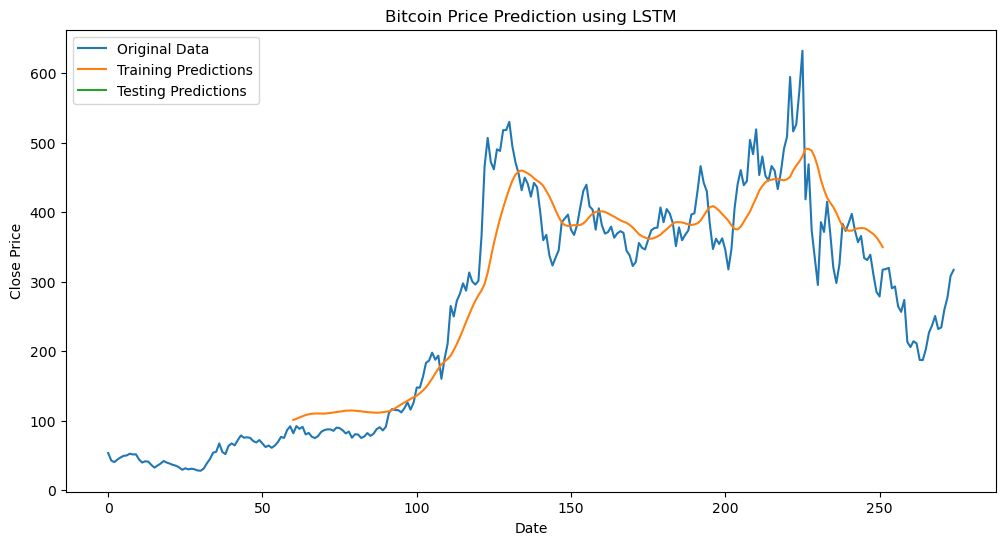

In [51]:
# Plot the predictions
plt.figure(figsize=(12,6))
plt.plot(scaler.inverse_transform(scaled_data), label='Original Data')
plt.plot(train_plot, label='Training Predictions')
plt.plot(test_plot, label='Testing Predictions')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Bitcoin Price Prediction using LSTM')
plt.legend()
plt.show()